# Unsupervised Machine Learning: Image Compression via K-Means Clustering

This notebook demonstrates color quantization using **K-Means Clustering** (`k-means++` initialization). 
We explore how reducing the number of distinct color vectors in 3D RGB space compresses images while preserving visual structure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
import io

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Create Synthetic Test Image (or Load Image)
We generate a test image containing rich color gradients to visualize color quantization.

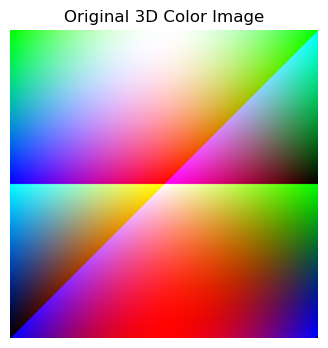

In [2]:
# Generate a colorful 200x200 test gradient image
x = np.linspace(0, 1, 200)
y = np.linspace(0, 1, 200)
xx, yy = np.meshgrid(x, y)

r = np.sin(xx * np.pi) * 255
g = np.cos(yy * np.pi) * 255
b = np.sin((xx + yy) * np.pi) * 255

img_array = np.dstack((r, g, b)).astype(np.uint8)
test_image = Image.fromarray(img_array)

plt.figure(figsize=(4, 4))
plt.imshow(test_image)
plt.title("Original 3D Color Image")
plt.axis('off')
plt.show()

## 2. Flattening Pixels for K-Means Clustering
Reshape image matrix `(Height, Width, 3)` into 2D feature matrix `(N_pixels, 3)`.

In [3]:
img_np = np.array(test_image)
height, width, channels = img_np.shape
pixels = img_np.reshape(-1, 3)

print(f"Original Image Shape: {img_np.shape}")
print(f"Reshaped Pixel Feature Array: {pixels.shape}")

Original Image Shape: (200, 200, 3)
Reshaped Pixel Feature Array: (40000, 3)


## 3. The Elbow Method (Finding Optimal K)
We calculate **Inertia** (Sum of Squared Errors to nearest centroids) for $K = 1 \dots 10$.

c:\Users\Dhruv\miniforge3\envs\my_workspace\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


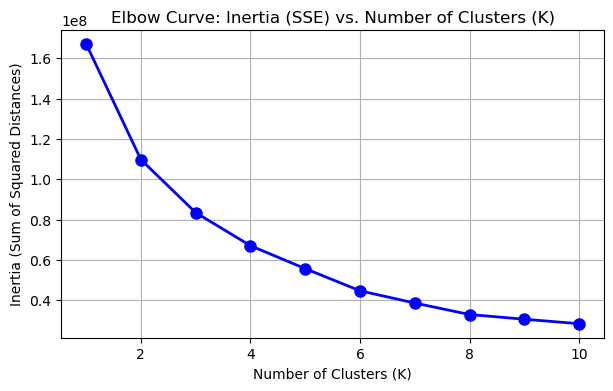

In [4]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(pixels[::5])  # Sub-sample every 5th pixel for fast evaluation
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Curve: Inertia (SSE) vs. Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()

## 4. Visualizing Color Quantization Across Different K Values

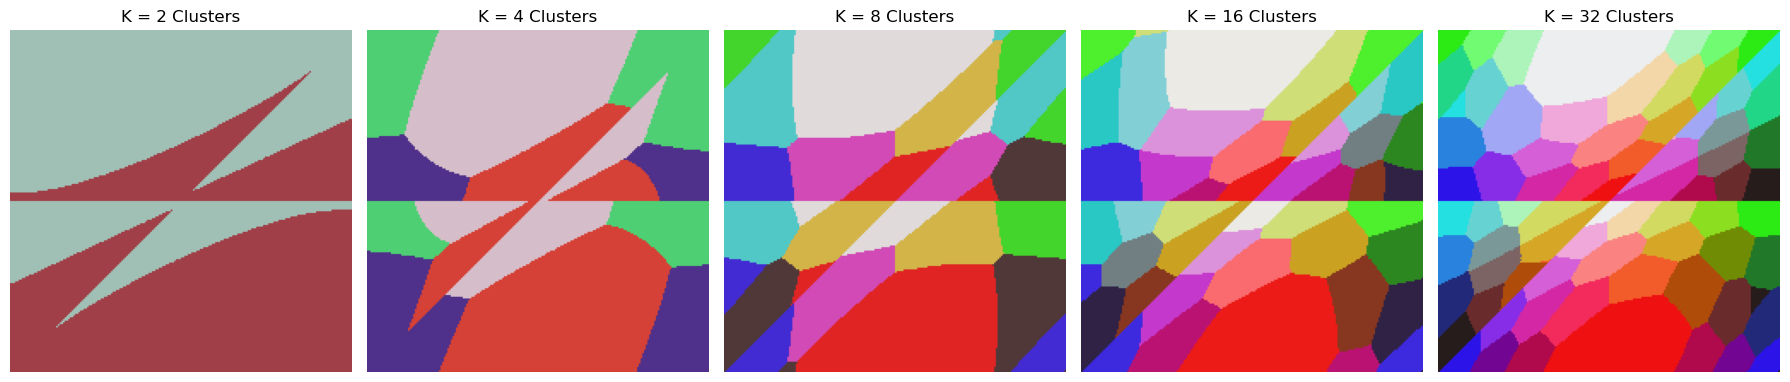

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
k_values = [2, 4, 8, 16, 32]

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(pixels)
    labels = kmeans.predict(pixels)
    centroids = kmeans.cluster_centers_.astype(np.uint8)
    quantized = centroids[labels].reshape(height, width, 3)
    
    axes[idx].imshow(quantized)
    axes[idx].set_title(f"K = {k} Clusters")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()